## 11 · Validación final del recomendador multimodal

Se comprueba que las distintas partes encajan correctamente: el análisis de Pareto, la personalización y la evaluación de estabilidad y robustez.

La alternativa sigue siendo: ***barrio × destino × modo de transporte***

Se mantienen los cuatro modos: *TRANSIT, WALK, BICYCLE y CAR*. El modo de transporte funciona como una preferencia del usuario, no como un objetivo adicional de Pareto.

**Objetivos:**
- Comprobar que los datos de los notebooks 08, 09 y 10 son coherentes.
- Verificar que se utilizan los mismos perfiles de usuario.
- Revisar las recomendaciones generadas para cada destino, modo y perfil.
- Comparar el método principal con los métodos de referencia.
- Resumir la robustez del recomendador para cada modo de transporte.
- Recoger las validaciones e hipótesis del notebook 10.
- Generar una síntesis final lista para usar en la memoria.

**NOTA:**Las validaciones estructurales deben cumplirse todas. Las hipótesis experimentales, en cambio, se interpretan según los resultados obtenidos, aunque alguna no se cumpla.

## 1. Importaciones


In [1]:
from __future__ import annotations

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import Markdown, display
from pandas.api.types import is_bool_dtype


In [2]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 180)

FLOAT_TOLERANCE = 1e-9

EXPECTED_TRANSPORT_MODES = {
    "TRANSIT": "Transporte público",
    "WALK": "A pie",
    "BICYCLE": "Bicicleta",
    "CAR": "Coche",
}

EXPECTED_PROFILE_WEIGHTS = {
    "price_priority": (0.75, 0.25),
    "balanced": (0.50, 0.50),
    "time_priority": (0.25, 0.75),
}

EXPECTED_DESTINATIONS = 3
EXPECTED_MODES = 4
EXPECTED_GROUPS = EXPECTED_DESTINATIONS * EXPECTED_MODES
EXPECTED_PROFILES = len(EXPECTED_PROFILE_WEIGHTS)
EXPECTED_PROFILE_SCENARIOS = EXPECTED_GROUPS * EXPECTED_PROFILES

MAIN_METHOD = "pareto_weighted"
NOISE_REFERENCE_LEVEL = 0.05


## 2. Localización del proyecto y contrato de archivos

Se utilizan rutas explícitas para evitar que el notebook seleccione accidentalmente resultados antiguos.

In [3]:
def find_project_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()

    for candidate in [current, *current.parents]:
        if (
            (candidate / "data").is_dir()
            and (candidate / "notebooks").is_dir()
        ):
            return candidate

    raise FileNotFoundError(
        "No se ha encontrado la raíz del proyecto. "
        "Debe contener las carpetas data/ y notebooks/."
    )


PROJECT_ROOT = find_project_root()
RESULTS_DIR = PROJECT_ROOT / "data" / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Notebook 08
PARETO_PATH = RESULTS_DIR / "pareto_by_destination_mode.csv"

# Notebook 09
PROFILE_DEFINITIONS_PATH = RESULTS_DIR / "recommendation_profiles.csv"
PROFILE_RECOMMENDATIONS_PATH = (
    RESULTS_DIR / "profile_recommendation_comparison_by_destination_mode.csv"
)
RECOMMENDER_VALIDATION_PATH = (
    RESULTS_DIR / "recommendation_engine_multimodal_validation.csv"
)

# Notebook 10
METHOD_DETAIL_PATH = (
    RESULTS_DIR / "evaluation_multimodal_method_comparison_detail.csv"
)
METHOD_SUMMARY_PATH = (
    RESULTS_DIR / "evaluation_multimodal_method_comparison_summary.csv"
)
METHOD_MODE_SUMMARY_PATH = (
    RESULTS_DIR / "evaluation_multimodal_method_summary_by_mode.csv"
)
WEIGHT_SUMMARY_PATH = (
    RESULTS_DIR / "evaluation_multimodal_weight_stability_summary.csv"
)
CONSTRAINT_SUMMARY_PATH = (
    RESULTS_DIR / "evaluation_multimodal_constraint_robustness_summary.csv"
)
NOISE_SUMMARY_PATH = (
    RESULTS_DIR / "evaluation_multimodal_noise_robustness_summary.csv"
)
NOISE_MODE_SUMMARY_PATH = (
    RESULTS_DIR / "evaluation_multimodal_noise_summary_by_mode.csv"
)
DIVERSITY_PATH = (
    RESULTS_DIR / "evaluation_multimodal_diversity_summary.csv"
)
PROFILE_DEPENDENCE_PATH = (
    RESULTS_DIR / "evaluation_multimodal_profile_dependence.csv"
)
HYPOTHESES_PATH = (
    RESULTS_DIR / "evaluation_multimodal_hypotheses.csv"
)
EXPERIMENT_VALIDATION_PATH = (
    RESULTS_DIR / "evaluation_multimodal_validation_report.csv"
)

# Salidas del notebook 11
PIPELINE_CONSISTENCY_PATH = (
    RESULTS_DIR / "final_multimodal_pipeline_consistency.csv"
)
METHOD_SCORECARD_PATH = (
    RESULTS_DIR / "final_multimodal_method_scorecard.csv"
)
MODE_SCORECARD_PATH = (
    RESULTS_DIR / "final_multimodal_mode_scorecard.csv"
)
EVIDENCE_SCORECARD_PATH = (
    RESULTS_DIR / "final_multimodal_evidence_scorecard.csv"
)
FINAL_HYPOTHESES_PATH = (
    RESULTS_DIR / "final_multimodal_empirical_hypotheses.csv"
)
FINAL_VALIDATION_PATH = (
    RESULTS_DIR / "final_multimodal_validation_report.csv"
)
FINAL_SUMMARY_PATH = (
    RESULTS_DIR / "final_multimodal_summary.csv"
)


In [4]:
required_paths = [
    PARETO_PATH,
    PROFILE_DEFINITIONS_PATH,
    PROFILE_RECOMMENDATIONS_PATH,
    RECOMMENDER_VALIDATION_PATH,
    METHOD_DETAIL_PATH,
    METHOD_SUMMARY_PATH,
    METHOD_MODE_SUMMARY_PATH,
    WEIGHT_SUMMARY_PATH,
    CONSTRAINT_SUMMARY_PATH,
    NOISE_SUMMARY_PATH,
    NOISE_MODE_SUMMARY_PATH,
    DIVERSITY_PATH,
    PROFILE_DEPENDENCE_PATH,
    HYPOTHESES_PATH,
    EXPERIMENT_VALIDATION_PATH,
]

missing_paths = [
    path
    for path in required_paths
    if not path.exists()
]

if missing_paths:
    formatted = "\n".join(
        f"- {path.relative_to(PROJECT_ROOT)}"
        for path in missing_paths
    )
    raise FileNotFoundError(
        "Faltan resultados necesarios de los notebooks 08, 09 o 10:\n"
        f"{formatted}\n\n"
        "Ejecuta primero esos notebooks con sus versiones multimodales definitivas."
    )

print("Raíz del proyecto:", PROJECT_ROOT)
print("Archivos de entrada comprobados:", len(required_paths))


Raíz del proyecto: C:\Users\clave\OneDrive\Documentos\ASIGNATURAS 5º INF-ADE\TFG INFO\TFG_Recomendador_Viviendas
Archivos de entrada comprobados: 15


## 3. Carga y validación de esquemas


In [5]:
pareto_data = pd.read_csv(PARETO_PATH)
profile_definitions = pd.read_csv(PROFILE_DEFINITIONS_PATH)
profile_recommendations = pd.read_csv(PROFILE_RECOMMENDATIONS_PATH)
recommender_validation = pd.read_csv(RECOMMENDER_VALIDATION_PATH)

method_detail = pd.read_csv(METHOD_DETAIL_PATH)
method_summary = pd.read_csv(METHOD_SUMMARY_PATH)
method_mode_summary = pd.read_csv(METHOD_MODE_SUMMARY_PATH)
weight_summary = pd.read_csv(WEIGHT_SUMMARY_PATH)
constraint_summary = pd.read_csv(CONSTRAINT_SUMMARY_PATH)
noise_summary = pd.read_csv(NOISE_SUMMARY_PATH)
noise_mode_summary = pd.read_csv(NOISE_MODE_SUMMARY_PATH)
diversity_summary = pd.read_csv(DIVERSITY_PATH)
profile_dependence = pd.read_csv(PROFILE_DEPENDENCE_PATH)
hypotheses = pd.read_csv(HYPOTHESES_PATH)
experiment_validation = pd.read_csv(EXPERIMENT_VALIDATION_PATH)

print("Pareto:", pareto_data.shape)
print("Perfiles:", profile_definitions.shape)
print("Recomendaciones 09:", profile_recommendations.shape)
print("Detalle evaluación 10:", method_detail.shape)
print("Hipótesis 10:", hypotheses.shape)
print("Validaciones 10:", experiment_validation.shape)


Pareto: (1457, 158)
Perfiles: (3, 4)
Recomendaciones 09: (36, 21)
Detalle evaluación 10: (891, 20)
Hipótesis 10: (5, 6)
Validaciones 10: (15, 4)


In [6]:
def require_columns(
    frame: pd.DataFrame,
    required: set[str],
    frame_name: str,
) -> None:
    missing = sorted(required - set(frame.columns))
    if missing:
        raise ValueError(
            f"Faltan columnas en {frame_name}: {missing}"
        )


def coerce_bool_column(
    frame: pd.DataFrame,
    column: str,
) -> pd.Series:
    values = frame[column]

    if is_bool_dtype(values):
        return values.astype(bool)

    mapping = {
        "true": True,
        "false": False,
        "1": True,
        "0": False,
    }

    converted = (
        values.astype(str)
        .str.strip()
        .str.lower()
        .map(mapping)
    )

    if converted.isna().any():
        invalid = sorted(
            values.loc[converted.isna()]
            .astype(str)
            .unique()
            .tolist()
        )
        raise ValueError(
            f"Valores booleanos no reconocidos en {column}: {invalid}"
        )

    return converted.astype(bool)


In [7]:
require_columns(
    pareto_data,
    {
        "zone_key",
        "neighborhood_name",
        "district_name",
        "destination_id",
        "destination_name",
        "transport_mode",
        "transport_mode_label",
        "price_m2_for_recommender",
        "commute_daily_minutes",
        "is_pareto",
    },
    "pareto_by_destination_mode.csv",
)

require_columns(
    profile_definitions,
    {
        "profile_id",
        "profile_name",
        "price_weight",
        "time_weight",
    },
    "recommendation_profiles.csv",
)

require_columns(
    profile_recommendations,
    {
        "destination_id",
        "destination_name",
        "transport_mode",
        "transport_mode_label",
        "profile_id",
        "profile_name",
        "price_weight",
        "time_weight",
        "zone_key",
        "neighborhood_name",
        "preference_score",
        "status",
        "is_pareto_eligible",
    },
    "profile_recommendation_comparison_by_destination_mode.csv",
)

require_columns(
    method_detail,
    {
        "destination_id",
        "destination_name",
        "transport_mode",
        "transport_mode_label",
        "profile_id",
        "profile_name",
        "method",
        "method_label",
        "price_weight",
        "time_weight",
        "rank",
        "zone_key",
        "neighborhood_name",
        "personalized_score",
        "is_pareto_eligible",
    },
    "evaluation_multimodal_method_comparison_detail.csv",
)

require_columns(
    method_summary,
    {
        "method",
        "method_label",
        "mean_top1_personalized_score",
        "pareto_efficiency_rate",
        "pareto_top1_rate",
        "scenarios",
    },
    "evaluation_multimodal_method_comparison_summary.csv",
)

require_columns(
    method_mode_summary,
    {
        "transport_mode",
        "transport_mode_label",
        "method",
        "pareto_efficiency_rate",
    },
    "evaluation_multimodal_method_summary_by_mode.csv",
)

require_columns(
    weight_summary,
    {
        "destination_id",
        "transport_mode",
        "transport_mode_label",
        "evaluated_weight_points",
        "unique_top1_neighborhoods",
        "top1_transitions",
        "mean_adjacent_jaccard_at_k",
        "min_adjacent_jaccard_at_k",
    },
    "evaluation_multimodal_weight_stability_summary.csv",
)

require_columns(
    constraint_summary,
    {
        "destination_id",
        "transport_mode",
        "transport_mode_label",
        "profile_id",
        "feasibility_rate",
        "base_top1_retention_rate",
        "mean_jaccard_vs_unconstrained",
    },
    "evaluation_multimodal_constraint_robustness_summary.csv",
)

require_columns(
    noise_mode_summary,
    {
        "transport_mode",
        "transport_mode_label",
        "noise_level",
        "mean_base_top1_retention_rate",
        "mean_base_top1_in_top_k_rate",
        "mean_jaccard_at_k",
    },
    "evaluation_multimodal_noise_summary_by_mode.csv",
)

require_columns(
    diversity_summary,
    {
        "method",
        "catalog_coverage_pct",
        "district_coverage_pct",
        "groups_changing_with_profile",
    },
    "evaluation_multimodal_diversity_summary.csv",
)

require_columns(
    profile_dependence,
    {
        "method",
        "destination_id",
        "transport_mode",
        "transport_mode_label",
        "changes_with_profile",
    },
    "evaluation_multimodal_profile_dependence.csv",
)

require_columns(
    hypotheses,
    {
        "hypothesis_id",
        "hypothesis",
        "metric",
        "value",
        "criterion",
        "passed",
    },
    "evaluation_multimodal_hypotheses.csv",
)

require_columns(
    recommender_validation,
    {
        "validation_id",
        "passed",
    },
    "recommendation_engine_multimodal_validation.csv",
)

require_columns(
    experiment_validation,
    {
        "validation_id",
        "passed",
    },
    "evaluation_multimodal_validation_report.csv",
)

pareto_data["is_pareto"] = coerce_bool_column(
    pareto_data,
    "is_pareto",
)
profile_recommendations["is_pareto_eligible"] = coerce_bool_column(
    profile_recommendations,
    "is_pareto_eligible",
)
method_detail["is_pareto_eligible"] = coerce_bool_column(
    method_detail,
    "is_pareto_eligible",
)
profile_dependence["changes_with_profile"] = coerce_bool_column(
    profile_dependence,
    "changes_with_profile",
)
hypotheses["passed"] = coerce_bool_column(
    hypotheses,
    "passed",
)
recommender_validation["passed"] = coerce_bool_column(
    recommender_validation,
    "passed",
)
experiment_validation["passed"] = coerce_bool_column(
    experiment_validation,
    "passed",
)

print("Contratos de columnas superados.")


Contratos de columnas superados.


## 4. Integridad de la matriz multimodal

La clave del dataset de Pareto es: ***zone_key + destination_id + transport_mode***

Se comprueba que los cuatro modos estén presentes y que existan las 12 combinaciones *destino–modo* esperadas.


In [8]:
ALTERNATIVE_KEY = [
    "zone_key",
    "destination_id",
    "transport_mode",
]

duplicate_alternatives = int(
    pareto_data.duplicated(
        subset=ALTERNATIVE_KEY
    ).sum()
)

if duplicate_alternatives:
    duplicated = pareto_data.loc[
        pareto_data.duplicated(
            subset=ALTERNATIVE_KEY,
            keep=False,
        )
    ].sort_values(ALTERNATIVE_KEY)
    display(duplicated.head(30))
    raise ValueError(
        "Hay alternativas barrio-destino-modo duplicadas."
    )

modes_present = set(
    pareto_data["transport_mode"]
    .dropna()
    .astype(str)
)

if modes_present != set(EXPECTED_TRANSPORT_MODES):
    raise ValueError(
        "Los modos del dataset no coinciden con los esperados. "
        f"Presentes: {sorted(modes_present)}"
    )

group_catalog = (
    pareto_data[
        [
            "destination_id",
            "destination_name",
            "transport_mode",
            "transport_mode_label",
        ]
    ]
    .drop_duplicates()
    .sort_values(
        [
            "destination_id",
            "transport_mode",
        ]
    )
    .reset_index(drop=True)
)

if pareto_data["destination_id"].nunique() != EXPECTED_DESTINATIONS:
    raise ValueError(
        "El número de destinos no coincide con el diseño experimental."
    )

if len(group_catalog) != EXPECTED_GROUPS:
    raise ValueError(
        f"Se esperaban {EXPECTED_GROUPS} grupos destino-modo "
        f"y se han encontrado {len(group_catalog)}."
    )

print("Alternativas:", len(pareto_data))
print("Barrios:", pareto_data["zone_key"].nunique())
print("Destinos:", pareto_data["destination_id"].nunique())
print("Modos:", pareto_data["transport_mode"].nunique())
print("Grupos destino-modo:", len(group_catalog))
display(group_catalog)


Alternativas: 1457
Barrios: 129
Destinos: 3
Modos: 4
Grupos destino-modo: 12


,destination_id,destination_name,transport_mode,transport_mode_label
0,DEST_001,Puerta del Sol,BICYCLE,Bicicleta
1,DEST_001,Puerta del Sol,CAR,Coche
2,DEST_001,Puerta del Sol,TRANSIT,Transporte público
3,DEST_001,Puerta del Sol,WALK,A pie
4,DEST_002,Nuevos Ministerios,BICYCLE,Bicicleta
5,DEST_002,Nuevos Ministerios,CAR,Coche
6,DEST_002,Nuevos Ministerios,TRANSIT,Transporte público
7,DEST_002,Nuevos Ministerios,WALK,A pie
8,DEST_003,UC3M Campus de Leganés,BICYCLE,Bicicleta
9,DEST_003,UC3M Campus de Leganés,CAR,Coche


## 5. Consistencia de los perfiles

El notebook 11 no define perfiles nuevos. Reutiliza los mismos tres perfiles de los notebooks 09 y 10:

- Prioridad al precio: 0,75 / 0,25;
- Equilibrado: 0,50 / 0,50;
- Prioridad al tiempo: 0,25 / 0,75.

Así se evita introducir una evaluación final con criterios distintos de los utilizados por el recomendador real.


In [9]:
profile_definitions = (
    profile_definitions
    .sort_values("profile_id")
    .reset_index(drop=True)
)

if profile_definitions["profile_id"].duplicated().any():
    raise ValueError("Hay profile_id duplicados.")

if set(profile_definitions["profile_id"]) != set(EXPECTED_PROFILE_WEIGHTS):
    raise ValueError(
        "Los perfiles no coinciden con los definidos para el recomendador multimodal."
    )

profile_weight_checks = []

for profile_id, (expected_price, expected_time) in (
    EXPECTED_PROFILE_WEIGHTS.items()
):
    row = profile_definitions.loc[
        profile_definitions["profile_id"].eq(profile_id)
    ].iloc[0]

    profile_weight_checks.append(
        np.isclose(
            float(row["price_weight"]),
            expected_price,
        )
        and np.isclose(
            float(row["time_weight"]),
            expected_time,
        )
        and np.isclose(
            float(row["price_weight"])
            + float(row["time_weight"]),
            1.0,
        )
    )

if not all(profile_weight_checks):
    raise ValueError(
        "Los pesos de los perfiles no coinciden con la definición esperada."
    )

display(profile_definitions)
print("Los tres perfiles son coherentes con el diseño del recomendador.")


,profile_id,profile_name,price_weight,time_weight
0,balanced,Perfil equilibrado,0.50,0.50
1,price_priority,Prioridad al precio,0.75,0.25
2,time_priority,Prioridad al tiempo,0.25,0.75


Los tres perfiles son coherentes con el diseño del recomendador.


## 6. Herencia de las validaciones de los notebooks 09 y 10

Antes de sintetizar resultados comprueba que las etapas anteriores terminaron sin incoherencias estructurales.

**NOTA:** Las hipótesis del notebook 10 se mantienen separadas de estas validaciones porque representan resultados experimentales, no contratos de integridad.


In [10]:
recommender_failed = recommender_validation.loc[
    ~recommender_validation["passed"]
]

experiment_failed = experiment_validation.loc[
    ~experiment_validation["passed"]
]

if not recommender_failed.empty:
    display(recommender_failed)
    raise AssertionError(
        "El notebook 09 contiene validaciones no superadas."
    )

if not experiment_failed.empty:
    display(experiment_failed)
    raise AssertionError(
        "El notebook 10 contiene validaciones estructurales no superadas."
    )

print(
    "Validaciones heredadas del notebook 09:",
    f"{int(recommender_validation['passed'].sum())}/{len(recommender_validation)}",
)
print(
    "Validaciones heredadas del notebook 10:",
    f"{int(experiment_validation['passed'].sum())}/{len(experiment_validation)}",
)


Validaciones heredadas del notebook 09: 16/16
Validaciones heredadas del notebook 10: 15/15


## 7. Validación cruzada entre recomendación y evaluación

Esta es la comprobación principal de integración.

Para cada combinación: ***destino × modo × perfil***

Se compara:

- La primera recomendación producida por el motor del notebook 09
- La primera recomendación reconstruida de forma independiente en el notebook 10 con *Pareto + suma ponderada*

Deben coincidir tanto el barrio seleccionado como la puntuación y los pesos. De esta forma se comprueba que la evaluación experimental está midiendo realmente el mismo recomendador que se ofrece al usuario.


In [11]:
PROFILE_SCENARIO_KEY = [
    "destination_id",
    "transport_mode",
    "profile_id",
]

profile_top1 = (
    profile_recommendations.loc[
        profile_recommendations["status"].eq(
            "recommended"
        )
    ]
    .copy()
)

evaluation_top1 = (
    method_detail.loc[
        method_detail["method"].eq(MAIN_METHOD)
        & method_detail["rank"].eq(1)
    ]
    .copy()
)

if profile_top1.duplicated(
    subset=PROFILE_SCENARIO_KEY
).any():
    raise ValueError(
        "El notebook 09 contiene más de una recomendación "
        "para un mismo destino-modo-perfil."
    )

if evaluation_top1.duplicated(
    subset=PROFILE_SCENARIO_KEY
).any():
    raise ValueError(
        "El notebook 10 contiene más de un top 1 principal "
        "para un mismo destino-modo-perfil."
    )

pipeline_consistency = (
    profile_top1[
        [
            *PROFILE_SCENARIO_KEY,
            "destination_name",
            "transport_mode_label",
            "profile_name",
            "price_weight",
            "time_weight",
            "zone_key",
            "neighborhood_name",
            "preference_score",
        ]
    ]
    .rename(
        columns={
            "zone_key": "zone_key_notebook_09",
            "neighborhood_name": "neighborhood_notebook_09",
            "preference_score": "score_notebook_09",
            "price_weight": "price_weight_notebook_09",
            "time_weight": "time_weight_notebook_09",
        }
    )
    .merge(
        evaluation_top1[
            [
                *PROFILE_SCENARIO_KEY,
                "price_weight",
                "time_weight",
                "zone_key",
                "neighborhood_name",
                "personalized_score",
                "is_pareto_eligible",
            ]
        ].rename(
            columns={
                "zone_key": "zone_key_notebook_10",
                "neighborhood_name": "neighborhood_notebook_10",
                "personalized_score": "score_notebook_10",
                "price_weight": "price_weight_notebook_10",
                "time_weight": "time_weight_notebook_10",
            }
        ),
        on=PROFILE_SCENARIO_KEY,
        how="outer",
        validate="one_to_one",
        indicator=True,
    )
)

pipeline_consistency["same_neighborhood"] = (
    pipeline_consistency["zone_key_notebook_09"]
    == pipeline_consistency["zone_key_notebook_10"]
)

pipeline_consistency["score_difference"] = (
    pd.to_numeric(
        pipeline_consistency["score_notebook_09"],
        errors="coerce",
    )
    - pd.to_numeric(
        pipeline_consistency["score_notebook_10"],
        errors="coerce",
    )
)

pipeline_consistency["same_score"] = (
    pipeline_consistency["score_difference"]
    .abs()
    .le(FLOAT_TOLERANCE)
)

pipeline_consistency["same_weights"] = (
    np.isclose(
        pipeline_consistency["price_weight_notebook_09"],
        pipeline_consistency["price_weight_notebook_10"],
        atol=FLOAT_TOLERANCE,
    )
    & np.isclose(
        pipeline_consistency["time_weight_notebook_09"],
        pipeline_consistency["time_weight_notebook_10"],
        atol=FLOAT_TOLERANCE,
    )
)

pipeline_consistency["pareto_efficient_in_evaluation"] = (
    pipeline_consistency["is_pareto_eligible"]
    .fillna(False)
    .astype(bool)
)

display(pipeline_consistency)


,destination_id,transport_mode,profile_id,destination_name,transport_mode_label,profile_name,price_weight_notebook_09,time_weight_notebook_09,zone_key_notebook_09,neighborhood_notebook_09,score_notebook_09,price_weight_notebook_10,time_weight_notebook_10,zone_key_notebook_10,neighborhood_notebook_10,score_notebook_10,is_pareto_eligible,_merge,same_neighborhood,score_difference,same_score,same_weights,pareto_efficient_in_evaluation
0,DEST_001,BICYCLE,balanced,Puerta del Sol,Bicicleta,Perfil equilibrado,0.50,0.50,MAD-102,Puerta del Ángel,0.160736,0.50,0.50,MAD-102,Puerta del Ángel,0.160736,True,both,True,-1.110223e-16,True,True,True
1,DEST_001,BICYCLE,price_priority,Puerta del Sol,Bicicleta,Prioridad al precio,0.75,0.25,MAD-121,Orcasitas,0.124648,0.75,0.25,MAD-121,Orcasitas,0.124648,True,both,True,0.000000e+00,True,True,True
2,DEST_001,BICYCLE,time_priority,Puerta del Sol,Bicicleta,Prioridad al tiempo,0.25,0.75,MAD-016,Sol,0.118594,0.25,0.75,MAD-016,Sol,0.118594,True,both,True,0.000000e+00,True,True,True
3,DEST_001,CAR,balanced,Puerta del Sol,Coche,Perfil equilibrado,0.50,0.50,MAD-134,Palomeras Sureste,0.171103,0.50,0.50,MAD-134,Palomeras Sureste,0.171103,True,both,True,0.000000e+00,True,True,True
4,DEST_001,CAR,price_priority,Puerta del Sol,Coche,Prioridad al precio,0.75,0.25,MAD-121,Orcasitas,0.115396,0.75,0.25,MAD-121,Orcasitas,0.115396,True,both,True,0.000000e+00,True,True,True
5,DEST_001,CAR,time_priority,Puerta del Sol,Coche,Prioridad al tiempo,0.25,0.75,MAD-015,Universidad,0.117847,0.25,0.75,MAD-015,Universidad,0.117847,True,both,True,0.000000e+00,True,True,True
6,DEST_001,TRANSIT,balanced,Puerta del Sol,Transporte público,Perfil equilibrado,0.50,0.50,MAD-102,Puerta del Ángel,0.110339,0.50,0.50,MAD-102,Puerta del Ángel,0.110339,True,both,True,0.000000e+00,True,True,True
7,DEST_001,TRANSIT,price_priority,Puerta del Sol,Transporte público,Prioridad al precio,0.75,0.25,MAD-172,San Cristóbal,0.110749,0.75,0.25,MAD-172,San Cristóbal,0.110749,True,both,True,0.000000e+00,True,True,True
8,DEST_001,TRANSIT,time_priority,Puerta del Sol,Transporte público,Prioridad al tiempo,0.25,0.75,MAD-102,Puerta del Ángel,0.078467,0.25,0.75,MAD-102,Puerta del Ángel,0.078467,True,both,True,-1.110223e-16,True,True,True
9,DEST_001,WALK,balanced,Puerta del Sol,A pie,Perfil equilibrado,0.50,0.50,MAD-102,Puerta del Ángel,0.175001,0.50,0.50,MAD-102,Puerta del Ángel,0.175001,True,both,True,-1.110223e-16,True,True,True


In [12]:
consistency_summary = pd.Series(
    {
        "expected_scenarios": EXPECTED_PROFILE_SCENARIOS,
        "scenarios_notebook_09": len(profile_top1),
        "scenarios_notebook_10": len(evaluation_top1),
        "merged_scenarios": len(pipeline_consistency),
        "rows_present_in_both": int(
            pipeline_consistency["_merge"].eq("both").sum()
        ),
        "same_neighborhood_percentage": (
            100
            * pipeline_consistency["same_neighborhood"].mean()
        ),
        "same_score_percentage": (
            100
            * pipeline_consistency["same_score"].mean()
        ),
        "same_weights_percentage": (
            100
            * pipeline_consistency["same_weights"].mean()
        ),
        "pareto_efficient_percentage": (
            100
            * pipeline_consistency[
                "pareto_efficient_in_evaluation"
            ].mean()
        ),
        "maximum_absolute_score_difference": (
            pipeline_consistency[
                "score_difference"
            ].abs().max()
        ),
    },
    name="value",
)

display(consistency_summary.to_frame())


,value
expected_scenarios,3.600000e+01
scenarios_notebook_09,3.600000e+01
scenarios_notebook_10,3.600000e+01
merged_scenarios,3.600000e+01
rows_present_in_both,3.600000e+01
same_neighborhood_percentage,1.000000e+02
same_score_percentage,1.000000e+02
same_weights_percentage,1.000000e+02
pareto_efficient_percentage,1.000000e+02
maximum_absolute_score_difference,1.110223e-16


## 8. Comparación de métodos

En el notebook 10 se compararon cinco estrategias distintas. Aquí se resumen esos resultados y se compara la mejor puntuación de cada método con la del método principal.

Es importante tener en cuenta que aplicar Pareto antes de la suma ponderada no tiene por qué dar una puntuación mejor que aplicar directamente la suma ponderada sobre todas las alternativas.

El principal valor de Pareto es que:

- Elimina opciones dominadas
- Asegura que las alternativas consideradas sean eficientes
- Hace más fácil interpretar las recomendaciones
- Mantiene la coherencia con el enfoque multiobjetivo del TFG

Por eso, si *pareto_weighted* y *weighted_all* dan el mismo resultado, no se considera un problema.

In [13]:
top1_all_methods = (
    method_detail.loc[
        method_detail["rank"].eq(1)
    ]
    .copy()
)

main_reference = (
    top1_all_methods.loc[
        top1_all_methods["method"].eq(MAIN_METHOD),
        [
            *PROFILE_SCENARIO_KEY,
            "zone_key",
            "personalized_score",
        ],
    ]
    .rename(
        columns={
            "zone_key": "main_zone_key",
            "personalized_score": "main_score",
        }
    )
)

top1_comparison = top1_all_methods.merge(
    main_reference,
    on=PROFILE_SCENARIO_KEY,
    how="left",
    validate="many_to_one",
)

top1_comparison["score_gap_vs_main"] = (
    top1_comparison["personalized_score"]
    - top1_comparison["main_score"]
)

top1_comparison["same_winner_as_main"] = (
    top1_comparison["zone_key"]
    == top1_comparison["main_zone_key"]
)

method_scorecard = (
    top1_comparison.groupby(
        ["method", "method_label"],
        as_index=False,
    )
    .agg(
        scenarios=("zone_key", "size"),
        mean_top1_score=("personalized_score", "mean"),
        mean_score_gap_vs_main=("score_gap_vs_main", "mean"),
        max_score_gap_vs_main=("score_gap_vs_main", "max"),
        same_winner_as_main_pct=(
            "same_winner_as_main",
            lambda s: 100 * s.mean(),
        ),
        pareto_top1_pct=(
            "is_pareto_eligible",
            lambda s: 100 * s.mean(),
        ),
        unique_top1_neighborhoods=("zone_key", "nunique"),
    )
    .sort_values(
        [
            "mean_top1_score",
            "method",
        ]
    )
    .reset_index(drop=True)
)

display(method_scorecard.round(4))


,method,method_label,scenarios,mean_top1_score,mean_score_gap_vs_main,max_score_gap_vs_main,same_winner_as_main_pct,pareto_top1_pct,unique_top1_neighborhoods
0,pareto_weighted,Pareto + suma ponderada,36,0.1019,0.0000,0.0000,100.0000,100.0,14
1,weighted_all,Suma ponderada sin filtro,36,0.1019,0.0000,0.0000,100.0000,100.0,14
2,ideal_distance,Distancia al punto ideal,36,0.1277,0.0258,0.0774,27.7778,100.0,7
3,fastest,Trayecto más rápido,36,0.2279,0.1260,0.6393,22.2222,100.0,8
4,cheapest,Barrio más barato,36,0.2402,0.1383,0.5371,13.8889,100.0,1


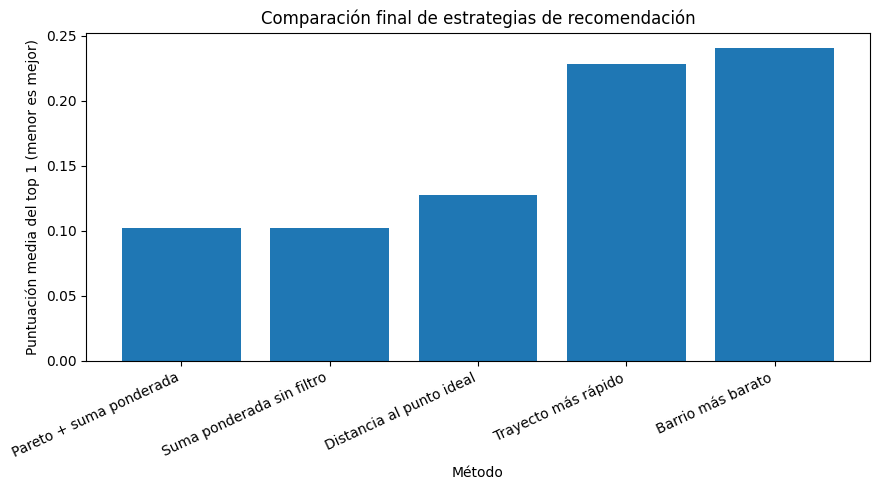

In [14]:
plot_methods = (
    method_scorecard
    .sort_values("mean_top1_score")
)

plt.figure(figsize=(9, 5))
plt.bar(
    plot_methods["method_label"],
    plot_methods["mean_top1_score"],
)
plt.ylabel("Puntuación media del top 1 (menor es mejor)")
plt.xlabel("Método")
plt.title("Comparación final de estrategias de recomendación")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()


## 9. Cuadro final de robustez por modo

Se integran cuatro dimensiones del notebook 10:

- Eficiencia Pareto del método principal;
- Estabilidad local al modificar los pesos;
- Robustez ante perturbaciones del 5 %;
- Efecto real de la personalización;
- Comportamiento bajo restricciones.

El objetivo es comprobar que el sistema no funciona bien únicamente de forma agregada, sino que mantiene un comportamiento interpretable en cada modo.


In [15]:
main_mode_method = (
    method_mode_summary.loc[
        method_mode_summary["method"].eq(MAIN_METHOD)
    ]
    [
        [
            "transport_mode",
            "transport_mode_label",
            "pareto_efficiency_rate",
        ]
    ]
    .drop_duplicates(
        subset=["transport_mode"]
    )
)

stability_by_mode = (
    weight_summary.groupby(
        [
            "transport_mode",
            "transport_mode_label",
        ],
        as_index=False,
    )
    .agg(
        mean_adjacent_jaccard_at_k=(
            "mean_adjacent_jaccard_at_k",
            "mean",
        ),
        min_adjacent_jaccard_at_k=(
            "min_adjacent_jaccard_at_k",
            "min",
        ),
        total_top1_transitions=(
            "top1_transitions",
            "sum",
        ),
        mean_unique_top1_neighborhoods=(
            "unique_top1_neighborhoods",
            "mean",
        ),
    )
)

noise_5_by_mode = (
    noise_mode_summary.loc[
        np.isclose(
            noise_mode_summary["noise_level"],
            NOISE_REFERENCE_LEVEL,
        )
    ]
    [
        [
            "transport_mode",
            "transport_mode_label",
            "mean_base_top1_retention_rate",
            "mean_base_top1_in_top_k_rate",
            "mean_jaccard_at_k",
        ]
    ]
    .copy()
)

main_profile_dependence = (
    profile_dependence.loc[
        profile_dependence["method"].eq(MAIN_METHOD)
    ]
    .copy()
)

personalization_by_mode = (
    main_profile_dependence.groupby(
        [
            "transport_mode",
            "transport_mode_label",
        ],
        as_index=False,
    )
    .agg(
        groups=("destination_id", "size"),
        groups_changing_with_profile=(
            "changes_with_profile",
            "sum",
        ),
    )
)

personalization_by_mode[
    "groups_changing_with_profile_pct"
] = (
    100
    * personalization_by_mode[
        "groups_changing_with_profile"
    ]
    / personalization_by_mode["groups"]
)

constraint_by_mode = (
    constraint_summary.groupby(
        [
            "transport_mode",
            "transport_mode_label",
        ],
        as_index=False,
    )
    .agg(
        mean_constraint_feasibility_rate=(
            "feasibility_rate",
            "mean",
        ),
        mean_constrained_top1_retention_rate=(
            "base_top1_retention_rate",
            "mean",
        ),
        mean_constraint_jaccard=(
            "mean_jaccard_vs_unconstrained",
            "mean",
        ),
    )
)

mode_scorecard = (
    main_mode_method
    .merge(
        stability_by_mode,
        on=[
            "transport_mode",
            "transport_mode_label",
        ],
        how="outer",
        validate="one_to_one",
    )
    .merge(
        noise_5_by_mode,
        on=[
            "transport_mode",
            "transport_mode_label",
        ],
        how="outer",
        validate="one_to_one",
    )
    .merge(
        personalization_by_mode,
        on=[
            "transport_mode",
            "transport_mode_label",
        ],
        how="outer",
        validate="one_to_one",
    )
    .merge(
        constraint_by_mode,
        on=[
            "transport_mode",
            "transport_mode_label",
        ],
        how="outer",
        validate="one_to_one",
    )
    .sort_values("transport_mode")
    .reset_index(drop=True)
)

display(mode_scorecard.round(4))


,transport_mode,transport_mode_label,pareto_efficiency_rate,mean_adjacent_jaccard_at_k,min_adjacent_jaccard_at_k,total_top1_transitions,mean_unique_top1_neighborhoods,mean_base_top1_retention_rate,mean_base_top1_in_top_k_rate,mean_jaccard_at_k,groups,groups_changing_with_profile,groups_changing_with_profile_pct,mean_constraint_feasibility_rate,mean_constrained_top1_retention_rate,mean_constraint_jaccard
0,BICYCLE,Bicicleta,100.0,0.9759,0.4286,11,4.6667,0.7240,0.9627,0.6431,3,3,100.0,1.0,0.8889,0.8625
1,CAR,Coche,100.0,0.9803,0.4286,12,5.0000,0.6560,0.8809,0.6287,3,3,100.0,1.0,0.8444,0.8171
2,TRANSIT,Transporte público,100.0,0.9844,0.6667,10,4.3333,0.7360,0.9889,0.6040,3,3,100.0,1.0,0.9556,0.8847
3,WALK,A pie,100.0,0.9811,0.6667,13,5.3333,0.6529,0.9147,0.6548,3,3,100.0,1.0,0.8667,0.8412


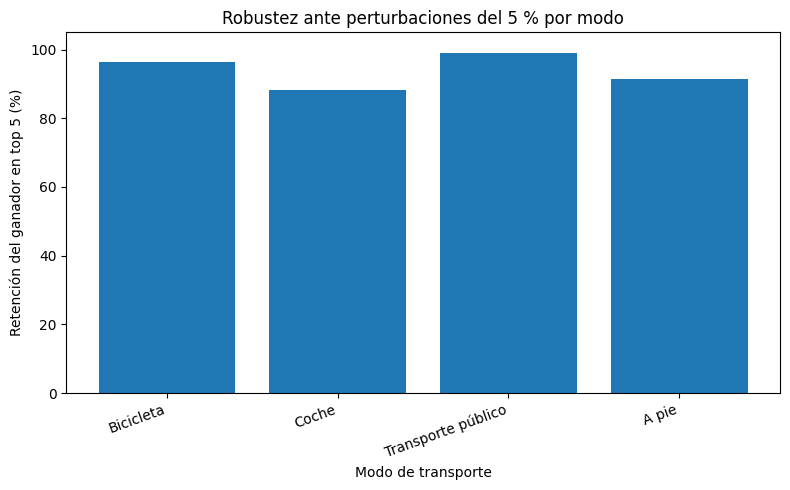

In [16]:
plt.figure(figsize=(8, 5))
plt.bar(
    mode_scorecard["transport_mode_label"],
    100
    * mode_scorecard[
        "mean_base_top1_in_top_k_rate"
    ],
)
plt.ylabel("Retención del ganador en top 5 (%)")
plt.xlabel("Modo de transporte")
plt.title("Robustez ante perturbaciones del 5 % por modo")
plt.ylim(0, 105)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()


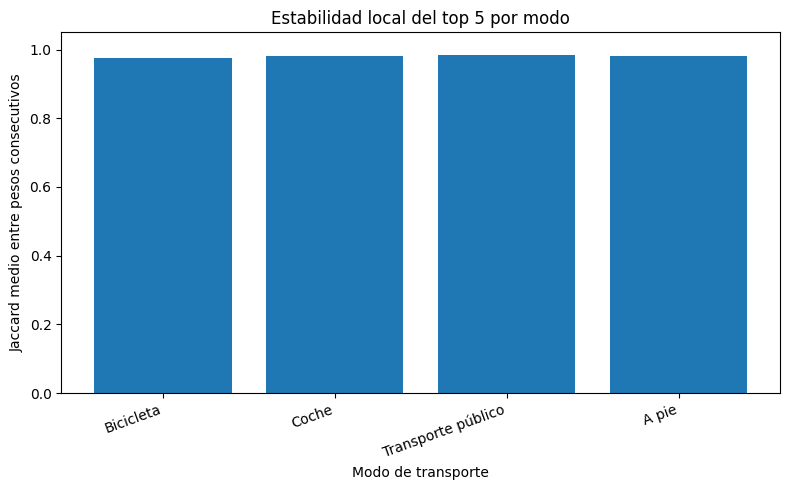

In [17]:
plt.figure(figsize=(8, 5))
plt.bar(
    mode_scorecard["transport_mode_label"],
    mode_scorecard[
        "mean_adjacent_jaccard_at_k"
    ],
)
plt.ylabel("Jaccard medio entre pesos consecutivos")
plt.xlabel("Modo de transporte")
plt.title("Estabilidad local del top 5 por modo")
plt.ylim(0, 1.05)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()


## 10. Hipótesis empíricas

Se reutilizan directamente las cinco hipótesis del notebook 10.

**NOTA:** No se recalibran umbrales después de observar los resultados. Esto evita convertir la evaluación final en una confirmación artificial del sistema.


In [18]:
hypotheses = (
    hypotheses
    .sort_values("hypothesis_id")
    .reset_index(drop=True)
)

display(hypotheses)

print(
    "Hipótesis superadas:",
    f"{int(hypotheses['passed'].sum())}/{len(hypotheses)}",
)


,hypothesis_id,hypothesis,metric,value,criterion,passed
0,H1,Las recomendaciones del método principal son Pareto-eficientes.,pareto_efficiency_rate,1.000000,== 1.00,True
1,H2,El top 5 es estable ante pequeños cambios consecutivos en los pesos.,mean_adjacent_jaccard_at_k,0.980437,>= 0.70,True
2,H3,"Con ruido del 5 %, el ganador original permanece dentro del top 5.",base_top1_in_top5_rate,0.936778,>= 0.80,True
3,H4,La personalización modifica el ganador en al menos un grupo destino–modo.,groups_changing_with_profile,12.000000,>= 1,True
4,H5,Los escenarios restringidos factibles mantienen eficiencia Pareto.,constraint_pareto_rate,1.000000,== 1.00,True


Hipótesis superadas: 5/5


## 11. Cuadro global de evidencia

La siguiente tabla resume los indicadores que más directamente responden a las preguntas de evaluación del sistema.


In [19]:
main_method_summary = (
    method_summary.loc[
        method_summary["method"].eq(MAIN_METHOD)
    ]
    .iloc[0]
)

main_diversity = (
    diversity_summary.loc[
        diversity_summary["method"].eq(MAIN_METHOD)
    ]
    .iloc[0]
)

mean_weight_jaccard = float(
    weight_summary[
        "mean_adjacent_jaccard_at_k"
    ].mean()
)

noise_5_global = (
    noise_summary.loc[
        np.isclose(
            noise_summary["noise_level"],
            NOISE_REFERENCE_LEVEL,
        )
    ]
)

if noise_5_global.empty:
    raise ValueError(
        "No existe el escenario de ruido del 5 %."
    )

noise_5_top5_retention = float(
    noise_5_global[
        "base_top1_in_top_k_rate"
    ].mean()
)

groups_changing = int(
    main_profile_dependence[
        "changes_with_profile"
    ].sum()
)

groups_evaluated_for_personalization = int(
    len(main_profile_dependence)
)

evidence_scorecard = pd.DataFrame(
    [
        {
            "indicator": "Pareto efficiency of main method",
            "value": float(
                main_method_summary[
                    "pareto_efficiency_rate"
                ]
            ),
            "unit": "%",
            "interpretation": (
                "Porcentaje de recomendaciones evaluadas "
                "que son Pareto-eficientes."
            ),
        },
        {
            "indicator": "Cross-notebook top1 agreement",
            "value": float(
                100
                * pipeline_consistency[
                    "same_neighborhood"
                ].mean()
            ),
            "unit": "%",
            "interpretation": (
                "Coincidencia del ganador entre notebooks 09 y 10."
            ),
        },
        {
            "indicator": "Mean adjacent top5 Jaccard",
            "value": mean_weight_jaccard,
            "unit": "0-1",
            "interpretation": (
                "Estabilidad local al modificar ligeramente los pesos."
            ),
        },
        {
            "indicator": "5% noise: original winner in top5",
            "value": 100 * noise_5_top5_retention,
            "unit": "%",
            "interpretation": (
                "Robustez del ganador ante perturbaciones del 5 %."
            ),
        },
        {
            "indicator": "Groups changing with profile",
            "value": groups_changing,
            "unit": (
                f"of {groups_evaluated_for_personalization}"
            ),
            "interpretation": (
                "Grupos destino-modo donde la personalización "
                "cambia la primera recomendación."
            ),
        },
        {
            "indicator": "Catalog coverage",
            "value": float(
                main_diversity["catalog_coverage_pct"]
            ),
            "unit": "%",
            "interpretation": (
                "Cobertura de barrios alcanzada por el método principal "
                "en la evaluación."
            ),
        },
        {
            "indicator": "Notebook 09 validations passed",
            "value": int(
                recommender_validation["passed"].sum()
            ),
            "unit": f"of {len(recommender_validation)}",
            "interpretation": "Integridad del motor personalizado.",
        },
        {
            "indicator": "Notebook 10 validations passed",
            "value": int(
                experiment_validation["passed"].sum()
            ),
            "unit": f"of {len(experiment_validation)}",
            "interpretation": "Integridad de la evaluación experimental.",
        },
        {
            "indicator": "Empirical hypotheses passed",
            "value": int(hypotheses["passed"].sum()),
            "unit": f"of {len(hypotheses)}",
            "interpretation": (
                "Resultado de las hipótesis operativas, "
                "sin reinterpretar sus umbrales."
            ),
        },
    ]
)

display(evidence_scorecard)


,indicator,value,unit,interpretation
0,Pareto efficiency of main method,100.000000,%,Porcentaje de recomendaciones evaluadas que son Pareto-eficientes.
1,Cross-notebook top1 agreement,100.000000,%,Coincidencia del ganador entre notebooks 09 y 10.
2,Mean adjacent top5 Jaccard,0.980437,0-1,Estabilidad local al modificar ligeramente los pesos.
3,5% noise: original winner in top5,93.677778,%,Robustez del ganador ante perturbaciones del 5 %.
4,Groups changing with profile,12.000000,of 12,Grupos destino-modo donde la personalización cambia la primera recomendación.
5,Catalog coverage,33.333333,%,Cobertura de barrios alcanzada por el método principal en la evaluación.
6,Notebook 09 validations passed,16.000000,of 16,Integridad del motor personalizado.
7,Notebook 10 validations passed,15.000000,of 15,Integridad de la evaluación experimental.
8,Empirical hypotheses passed,5.000000,of 5,"Resultado de las hipótesis operativas, sin reinterpretar sus umbrales."


## 12. Validaciones finales del notebook 11

Las validaciones del notebook 11 se centran en la **coherencia entre etapas**, no en repetir todas las pruebas ya realizadas.

Se distinguen:

- ***structural***: Deben superarse para considerar íntegro el pipeline;
- ***empirical***: Resumen evidencia experimental, pero conceptualmente no redefine la validez estructural.


In [20]:
validation_rows = []


def add_validation(
    validation_id: str,
    description: str,
    passed: bool,
    detail: str,
    validation_type: str = "structural",
) -> None:
    validation_rows.append(
        {
            "validation_id": validation_id,
            "validation_type": validation_type,
            "description": description,
            "passed": bool(passed),
            "detail": detail,
        }
    )


add_validation(
    "unique_alternatives",
    "No hay alternativas barrio-destino-modo duplicadas.",
    duplicate_alternatives == 0,
    f"Duplicados: {duplicate_alternatives}",
)

add_validation(
    "exact_transport_modes",
    "Están presentes exactamente los cuatro modos esperados.",
    modes_present == set(EXPECTED_TRANSPORT_MODES),
    f"Modos: {sorted(modes_present)}",
)

add_validation(
    "complete_destination_mode_matrix",
    "Existen las 12 combinaciones destino-modo.",
    len(group_catalog) == EXPECTED_GROUPS,
    (
        f"Esperadas: {EXPECTED_GROUPS}; "
        f"presentes: {len(group_catalog)}"
    ),
)

add_validation(
    "profile_contract",
    "Los tres perfiles y sus pesos coinciden con el diseño del recomendador.",
    (
        set(profile_definitions["profile_id"])
        == set(EXPECTED_PROFILE_WEIGHTS)
        and all(profile_weight_checks)
    ),
    f"Perfiles comprobados: {len(profile_definitions)}",
)

add_validation(
    "notebook09_validations",
    "Todas las validaciones estructurales del notebook 09 están superadas.",
    recommender_validation["passed"].all(),
    (
        f"Superadas: {int(recommender_validation['passed'].sum())}"
        f"/{len(recommender_validation)}"
    ),
)

add_validation(
    "notebook10_validations",
    "Todas las validaciones estructurales del notebook 10 están superadas.",
    experiment_validation["passed"].all(),
    (
        f"Superadas: {int(experiment_validation['passed'].sum())}"
        f"/{len(experiment_validation)}"
    ),
)

add_validation(
    "profile_scenario_coverage_09",
    "El notebook 09 contiene las 36 recomendaciones destino-modo-perfil.",
    (
        len(profile_top1) == EXPECTED_PROFILE_SCENARIOS
        and not profile_top1.duplicated(
            subset=PROFILE_SCENARIO_KEY
        ).any()
    ),
    (
        f"Esperadas: {EXPECTED_PROFILE_SCENARIOS}; "
        f"presentes: {len(profile_top1)}"
    ),
)

add_validation(
    "profile_scenario_coverage_10",
    "El método principal del notebook 10 contiene los 36 top 1 esperados.",
    (
        len(evaluation_top1) == EXPECTED_PROFILE_SCENARIOS
        and not evaluation_top1.duplicated(
            subset=PROFILE_SCENARIO_KEY
        ).any()
    ),
    (
        f"Esperadas: {EXPECTED_PROFILE_SCENARIOS}; "
        f"presentes: {len(evaluation_top1)}"
    ),
)

add_validation(
    "cross_notebook_membership",
    "Todos los escenarios aparecen simultáneamente en notebooks 09 y 10.",
    (
        len(pipeline_consistency)
        == EXPECTED_PROFILE_SCENARIOS
        and pipeline_consistency["_merge"].eq("both").all()
    ),
    (
        f"Filas coincidentes: "
        f"{int(pipeline_consistency['_merge'].eq('both').sum())}"
        f"/{EXPECTED_PROFILE_SCENARIOS}"
    ),
)

add_validation(
    "cross_notebook_winner",
    "El barrio top 1 coincide entre notebooks 09 y 10.",
    pipeline_consistency["same_neighborhood"].all(),
    (
        "Coincidencias: "
        f"{int(pipeline_consistency['same_neighborhood'].sum())}"
        f"/{len(pipeline_consistency)}"
    ),
)

add_validation(
    "cross_notebook_score",
    "La puntuación del ganador coincide entre notebooks 09 y 10.",
    pipeline_consistency["same_score"].all(),
    (
        "Diferencia absoluta máxima: "
        f"{pipeline_consistency['score_difference'].abs().max():.3e}"
    ),
)

add_validation(
    "cross_notebook_weights",
    "Los pesos utilizados coinciden entre notebooks 09 y 10.",
    pipeline_consistency["same_weights"].all(),
    (
        "Coincidencias: "
        f"{int(pipeline_consistency['same_weights'].sum())}"
        f"/{len(pipeline_consistency)}"
    ),
)

main_efficiency = float(
    main_method_summary["pareto_efficiency_rate"]
)

add_validation(
    "main_method_pareto_efficiency",
    "El método principal mantiene eficiencia Pareto total.",
    np.isclose(main_efficiency, 100.0),
    f"Eficiencia Pareto: {main_efficiency:.2f} %",
)

add_validation(
    "noise_mode_coverage",
    "La robustez al 5 % contiene los cuatro modos.",
    (
        set(noise_5_by_mode["transport_mode"])
        == set(EXPECTED_TRANSPORT_MODES)
        and len(noise_5_by_mode) == EXPECTED_MODES
    ),
    (
        "Modos en ruido 5 %: "
        f"{sorted(noise_5_by_mode['transport_mode'].tolist())}"
    ),
)

expected_hypotheses = {
    "H1",
    "H2",
    "H3",
    "H4",
    "H5",
}

add_validation(
    "hypothesis_contract",
    "La evaluación contiene las cinco hipótesis H1-H5.",
    set(hypotheses["hypothesis_id"]) == expected_hypotheses,
    (
        "Hipótesis: "
        f"{sorted(hypotheses['hypothesis_id'].tolist())}"
    ),
)

add_validation(
    "empirical_hypotheses_result",
    "Resultado observado de las hipótesis operativas.",
    hypotheses["passed"].all(),
    (
        f"Superadas: {int(hypotheses['passed'].sum())}"
        f"/{len(hypotheses)}"
    ),
    validation_type="empirical",
)

final_validation = pd.DataFrame(validation_rows)

display(final_validation)


,validation_id,validation_type,description,passed,detail
0,unique_alternatives,structural,No hay alternativas barrio-destino-modo duplicadas.,True,Duplicados: 0
1,exact_transport_modes,structural,Están presentes exactamente los cuatro modos esperados.,True,"Modos: ['BICYCLE', 'CAR', 'TRANSIT', 'WALK']"
2,complete_destination_mode_matrix,structural,Existen las 12 combinaciones destino-modo.,True,Esperadas: 12; presentes: 12
3,profile_contract,structural,Los tres perfiles y sus pesos coinciden con el diseño del recomendador.,True,Perfiles comprobados: 3
4,notebook09_validations,structural,Todas las validaciones estructurales del notebook 09 están superadas.,True,Superadas: 16/16
5,notebook10_validations,structural,Todas las validaciones estructurales del notebook 10 están superadas.,True,Superadas: 15/15
6,profile_scenario_coverage_09,structural,El notebook 09 contiene las 36 recomendaciones destino-modo-perfil.,True,Esperadas: 36; presentes: 36
7,profile_scenario_coverage_10,structural,El método principal del notebook 10 contiene los 36 top 1 esperados.,True,Esperadas: 36; presentes: 36
8,cross_notebook_membership,structural,Todos los escenarios aparecen simultáneamente en notebooks 09 y 10.,True,Filas coincidentes: 36/36
9,cross_notebook_winner,structural,El barrio top 1 coincide entre notebooks 09 y 10.,True,Coincidencias: 36/36


In [21]:
structural_failures = final_validation.loc[
    final_validation["validation_type"].eq("structural")
    & ~final_validation["passed"]
]

if not structural_failures.empty:
    display(
        Markdown(
            "### Validaciones estructurales no superadas"
        )
    )
    display(structural_failures)
    raise AssertionError(
        "La validación final ha detectado incoherencias "
        "entre las etapas del pipeline."
    )

print(
    "Todas las validaciones estructurales del notebook 11 "
    "se han superado correctamente."
)

print(
    "Hipótesis empíricas superadas:",
    f"{int(hypotheses['passed'].sum())}/{len(hypotheses)}",
)


Todas las validaciones estructurales del notebook 11 se han superado correctamente.
Hipótesis empíricas superadas: 5/5


## 13. Exportación

Los resultados finales se guardan con el prefijo *final_multimodal_* para diferenciarlos de las salidas intermedias de los notebooks anteriores.


In [22]:
pipeline_consistency.to_csv(
    PIPELINE_CONSISTENCY_PATH,
    index=False,
    encoding="utf-8-sig",
)

method_scorecard.to_csv(
    METHOD_SCORECARD_PATH,
    index=False,
    encoding="utf-8-sig",
)

mode_scorecard.to_csv(
    MODE_SCORECARD_PATH,
    index=False,
    encoding="utf-8-sig",
)

evidence_scorecard.to_csv(
    EVIDENCE_SCORECARD_PATH,
    index=False,
    encoding="utf-8-sig",
)

hypotheses.to_csv(
    FINAL_HYPOTHESES_PATH,
    index=False,
    encoding="utf-8-sig",
)

final_validation.to_csv(
    FINAL_VALIDATION_PATH,
    index=False,
    encoding="utf-8-sig",
)

final_summary = pd.Series(
    {
        "pareto_input_rows": len(pareto_data),
        "neighborhoods": pareto_data["zone_key"].nunique(),
        "destinations": pareto_data["destination_id"].nunique(),
        "transport_modes": pareto_data["transport_mode"].nunique(),
        "destination_mode_groups": len(group_catalog),
        "profiles": len(profile_definitions),
        "profile_scenarios": len(pipeline_consistency),
        "methods_evaluated": method_scorecard["method"].nunique(),
        "notebook09_validations_passed": int(
            recommender_validation["passed"].sum()
        ),
        "notebook09_validations_total": len(
            recommender_validation
        ),
        "notebook10_validations_passed": int(
            experiment_validation["passed"].sum()
        ),
        "notebook10_validations_total": len(
            experiment_validation
        ),
        "cross_notebook_top1_matches": int(
            pipeline_consistency[
                "same_neighborhood"
            ].sum()
        ),
        "cross_notebook_top1_total": len(
            pipeline_consistency
        ),
        "hypotheses_passed": int(
            hypotheses["passed"].sum()
        ),
        "hypotheses_total": len(hypotheses),
        "notebook11_structural_validations_passed": int(
            final_validation.loc[
                final_validation[
                    "validation_type"
                ].eq("structural"),
                "passed",
            ].sum()
        ),
        "notebook11_structural_validations_total": int(
            final_validation[
                "validation_type"
            ].eq("structural").sum()
        ),
    },
    name="value",
)

final_summary.to_csv(
    FINAL_SUMMARY_PATH,
    header=["value"],
    encoding="utf-8-sig",
)

display(final_summary.to_frame())


,value
pareto_input_rows,1457
neighborhoods,129
destinations,3
transport_modes,4
destination_mode_groups,12
profiles,3
profile_scenarios,36
methods_evaluated,5
notebook09_validations_passed,16
notebook09_validations_total,16


In [23]:
generated_paths = [
    PIPELINE_CONSISTENCY_PATH,
    METHOD_SCORECARD_PATH,
    MODE_SCORECARD_PATH,
    EVIDENCE_SCORECARD_PATH,
    FINAL_HYPOTHESES_PATH,
    FINAL_VALIDATION_PATH,
    FINAL_SUMMARY_PATH,
]

missing_exports = [
    path
    for path in generated_paths
    if not path.exists()
]

if missing_exports:
    raise FileNotFoundError(
        "No se han generado todos los archivos finales: "
        f"{missing_exports}"
    )

print("Archivos finales generados correctamente:")
for path in generated_paths:
    print(
        "-",
        path.relative_to(PROJECT_ROOT),
    )


Archivos finales generados correctamente:
- data\results\final_multimodal_pipeline_consistency.csv
- data\results\final_multimodal_method_scorecard.csv
- data\results\final_multimodal_mode_scorecard.csv
- data\results\final_multimodal_evidence_scorecard.csv
- data\results\final_multimodal_empirical_hypotheses.csv
- data\results\final_multimodal_validation_report.csv
- data\results\final_multimodal_summary.csv


## 14. Interpretación metodológica final

La evaluación conjunta permite separar tres conceptos que conviene no confundir:

### 1. Eficiencia

El frente de Pareto elimina alternativas dominadas. Una recomendación eficiente no implica que sea universalmente la mejor; significa que no existe otra alternativa comparable que mejore simultáneamente precio y tiempo.

### 2. Preferencia

Los pesos determinan qué alternativa eficiente encaja mejor con las prioridades del usuario. Por ello, que el ganador cambie entre perfiles es una propiedad esperada y deseable si existe un trade-off real.

### 3. Robustez

Una recomendación puede ser eficiente y personalizada, pero sensible a pequeños cambios de pesos o a incertidumbre en los datos. El notebook 10 mide esta dimensión mediante estabilidad local, restricciones y perturbaciones *Monte Carlo*. El notebook 11 conserva esa evidencia y la presenta también por modo de transporte.

### Papel del filtrado Pareto

La suma ponderada aplicada a todo el conjunto puede seleccionar la misma solución que la suma ponderada aplicada al frente. Esto es compatible con la teoría de optimización multiobjetivo: un óptimo de una suma ponderada con pesos positivos no debería estar estrictamente dominado.

Por tanto, el aporte de Pareto en este TFG no se justifica por prometer una puntuación menor que la búsqueda exhaustiva, sino por estructurar el espacio de decisión, eliminar soluciones ineficientes y hacer explícito el compromiso precio–tiempo.


## 15. Limitaciones de la evaluación final

Aunque el pipeline se valida de forma extensa, la evaluación sigue siendo **offline** y debe interpretarse dentro del alcance del TFG.

- No se ha realizado un experimento con usuarios reales ni una prueba A/B.
- Los perfiles representan configuraciones reproducibles de preferencias, no segmentos poblacionales estimados estadísticamente.
- Los precios son referencias territoriales por metro cuadrado y no valoraciones de viviendas concretas.
- Los tiempos dependen de la fecha, los horarios, la coordenada representativa del barrio y los datos de routing disponibles.
- El coche no incorpora tráfico en tiempo real.
- Los recorridos a pie y en bicicleta dependen de la representación de la red en OpenStreetMap.
- Las perturbaciones Monte Carlo del notebook 10 evalúan sensibilidad numérica, pero no constituyen un modelo probabilístico completo del mercado inmobiliario ni de la movilidad.
- El modo de transporte se selecciona como una preferencia categórica y no como un objetivo simultáneo adicional.

Estas limitaciones no impiden comparar de forma homogénea las alternativas dentro del sistema, pero delimitan qué conclusiones pueden generalizarse fuera del experimento.


## 16. Conclusión

Este notebook cierra la validación del recomendador multimodal sin introducir un nuevo algoritmo.

La aportación principal es comprobar la **coherencia extremo a extremo** del pipeline: las recomendaciones generadas por el notebook 09 deben coincidir con las reconstruidas independientemente por el notebook 10 para las mismas combinaciones destino–modo–perfil. Además, se integran en una única lectura final la eficiencia Pareto, la estabilidad frente a los pesos, la robustez ante restricciones y perturbaciones, la diversidad y el efecto de la personalización.

El resultado final permite defender el sistema en tres niveles:

1. **integridad estructural**, mediante contratos y validaciones automáticas;
2. **coherencia algorítmica**, mediante la coincidencia entre personalización y evaluación independiente;
3. **evidencia empírica**, mediante las hipótesis y métricas de robustez.

De esta forma, el sistema queda preparado para su uso posterior en la aplicación interactiva y para documentar en la memoria del TFG tanto sus resultados como sus limitaciones.


In [24]:
display(
    Markdown(
        f'''
### Resumen final automático

- Alternativas analizadas: **{len(pareto_data):,}**
- Barrios con alternativas válidas: **{pareto_data["zone_key"].nunique()}**
- Destinos: **{pareto_data["destination_id"].nunique()}**
- Modos de transporte: **{pareto_data["transport_mode"].nunique()}**
- Grupos destino-modo: **{len(group_catalog)}**
- Escenarios destino-modo-perfil validados: **{len(pipeline_consistency)}**
- Coincidencia del top 1 entre notebooks 09 y 10: **{100 * pipeline_consistency["same_neighborhood"].mean():.2f} %**
- Eficiencia Pareto del método principal: **{main_efficiency:.2f} %**
- Jaccard medio entre pesos consecutivos: **{mean_weight_jaccard:.3f}**
- Retención del ganador dentro del top 5 con ruido del 5 %: **{100 * noise_5_top5_retention:.2f} %**
- Grupos donde la personalización cambia el ganador: **{groups_changing}/{groups_evaluated_for_personalization}**
- Hipótesis operativas superadas: **{int(hypotheses["passed"].sum())}/{len(hypotheses)}**
- Validaciones estructurales del notebook 11 superadas: **{int(final_validation.loc[final_validation["validation_type"].eq("structural"), "passed"].sum())}/{int(final_validation["validation_type"].eq("structural").sum())}**

**Notebook 11 multimodal finalizado correctamente.**
'''
    )
)



### Resumen final automático

- Alternativas analizadas: **1,457**
- Barrios con alternativas válidas: **129**
- Destinos: **3**
- Modos de transporte: **4**
- Grupos destino-modo: **12**
- Escenarios destino-modo-perfil validados: **36**
- Coincidencia del top 1 entre notebooks 09 y 10: **100.00 %**
- Eficiencia Pareto del método principal: **100.00 %**
- Jaccard medio entre pesos consecutivos: **0.980**
- Retención del ganador dentro del top 5 con ruido del 5 %: **93.68 %**
- Grupos donde la personalización cambia el ganador: **12/12**
- Hipótesis operativas superadas: **5/5**
- Validaciones estructurales del notebook 11 superadas: **15/15**

**Notebook 11 multimodal finalizado correctamente.**
